In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [40]:
pd.set_option('display.max_columns', None)
dfInit = pd.read_csv('student_lifestyle_dataset.csv', delimiter=',', encoding='utf-8')
df = dfInit.copy(deep=True)
display(df)

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Stress_Level,Gender,Grades
0,1,6.9,3.8,8.7,2.8,1.8,Moderate,Male,7.48
1,2,5.3,3.5,8.0,4.2,3.0,Low,Female,6.88
2,3,5.1,3.9,9.2,1.2,4.6,Low,Male,6.68
3,4,6.5,2.1,7.2,1.7,6.5,Moderate,Male,7.20
4,5,8.1,0.6,6.5,2.2,6.6,High,Male,8.78
...,...,...,...,...,...,...,...,...,...
1995,1996,6.5,0.2,7.4,2.1,7.8,Moderate,Male,8.30
1996,1997,6.3,2.8,8.8,1.5,4.6,Moderate,Female,6.62
1997,1998,6.2,0.0,6.2,0.8,10.8,Moderate,Male,7.85
1998,1999,8.1,0.7,7.6,3.5,4.1,High,Male,7.60


In [41]:
genderDict = { "Male" : 0, "Female" : 1 }
stressDict = {"Low" : 0, "High" : 1, "Moderate" : 2}
df["Gender"] = df["Gender"].map(lambda elem : genderDict[elem])
df["Stress_Level"] = df["Stress_Level"].map(lambda elem : stressDict[elem])
display(df)

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Stress_Level,Gender,Grades
0,1,6.9,3.8,8.7,2.8,1.8,2,0,7.48
1,2,5.3,3.5,8.0,4.2,3.0,0,1,6.88
2,3,5.1,3.9,9.2,1.2,4.6,0,0,6.68
3,4,6.5,2.1,7.2,1.7,6.5,2,0,7.20
4,5,8.1,0.6,6.5,2.2,6.6,1,0,8.78
...,...,...,...,...,...,...,...,...,...
1995,1996,6.5,0.2,7.4,2.1,7.8,2,0,8.30
1996,1997,6.3,2.8,8.8,1.5,4.6,2,1,6.62
1997,1998,6.2,0.0,6.2,0.8,10.8,2,0,7.85
1998,1999,8.1,0.7,7.6,3.5,4.1,1,0,7.60


In [42]:
x = df.drop(["Stress_Level"], axis=1)
y = df["Stress_Level"]

xTrain, xTest, yTrain, yTest = train_test_split(x, y, test_size=0.3, random_state=42)

In [43]:
scaler = StandardScaler()
scaler.fit(xTrain)
xTrainTransform = scaler.transform(xTrain)
xTestTransform = scaler.transform(xTest)

In [44]:
def calc_accuracy(mlpcClf: MLPClassifier):
    mlpcClf.fit(xTrainTransform, yTrain)
    return mlpcClf.score(xTestTransform, yTest)

layerSize=(50,), accuracy: 0.925
layerSize=(100,), accuracy: 0.895
layerSize=(150,), accuracy: 0.94
layerSize=(200,), accuracy: 0.925
layerSize=(250,), accuracy: 0.925
layerSize=(300,), accuracy: 0.94
layerSize=(350,), accuracy: 0.9466666666666667
layerSize=(400,), accuracy: 0.935
layerSize=(450,), accuracy: 0.945
layerSize=(500,), accuracy: 0.945
layerSize=(750,), accuracy: 0.9433333333333334
layerSize=(1000,), accuracy: 0.9366666666666666


Text(0, 0.5, 'accuracy')

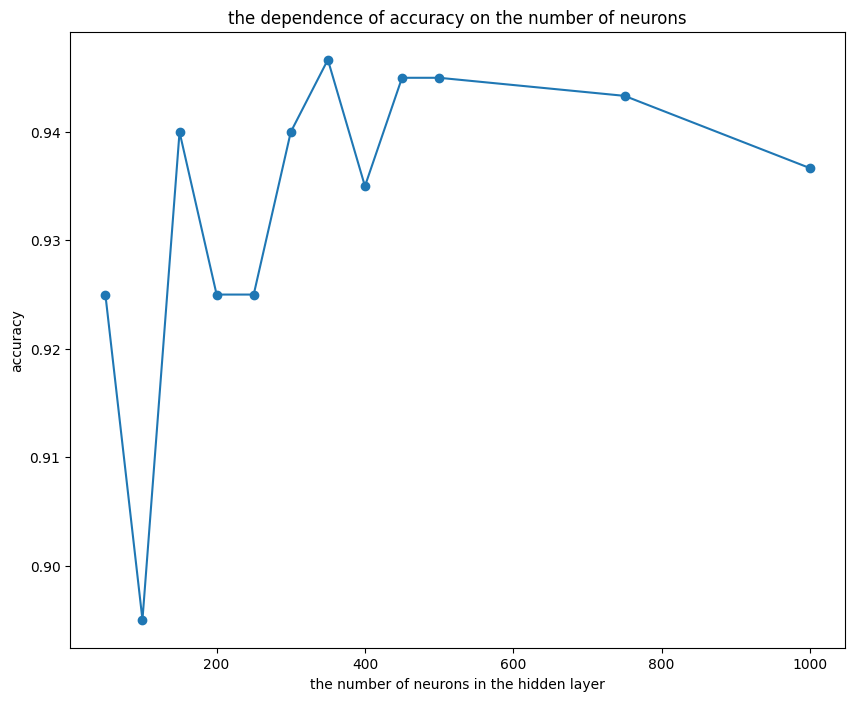

In [45]:
hiddenLayerSize = [(50,), (100,), (150,), (200,), (250,), (300,), (350,), (400,), (450,), (500,), (750,), (1000,)]

accuracies = []
for LayerSize in hiddenLayerSize:
    mlpcClf = MLPClassifier(
        solver='adam',
        hidden_layer_sizes=LayerSize,
        max_iter=1000,
        early_stopping=True,
        random_state=42
    )
    accuracies.append(calc_accuracy(mlpcClf))
    print(f'layerSize={LayerSize}, accuracy: {calc_accuracy(mlpcClf)}')

layerSizes = [size[0] for size in hiddenLayerSize]

plt.figure(figsize=(10, 8))
plt.plot(layerSizes, accuracies, marker='o')
plt.title('the dependence of accuracy on the number of neurons')
plt.xlabel('the number of neurons in the hidden layer')
plt.ylabel('accuracy')

In [46]:
solvers = ['sgd', 'adam', 'lbfgs']
for solver in solvers:
    mlpcClf = MLPClassifier(
        solver=solver,
        hidden_layer_sizes=(350,),
        early_stopping=True,
        random_state=42
    )
    print(f'solver={solver}, accuracy: {calc_accuracy(mlpcClf)}')

solver=sgd, accuracy: 0.7766666666666666
solver=adam, accuracy: 0.9466666666666667
solver=lbfgs, accuracy: 0.9716666666666667


In [47]:
activationFunctions = [
    'identity',
    'logistic',
    'tanh',
    'relu',
]
for func in activationFunctions:
    mlpcClf = MLPClassifier(
        solver='lbfgs',
        hidden_layer_sizes=(350,),
        # max_iter=1000,
        early_stopping=True,
        activation=func,
        random_state=42
    )
    print (f'func={func}, accuracy: {calc_accuracy(mlpcClf)}')

func=identity, accuracy: 0.8283333333333334
func=logistic, accuracy: 0.95
func=tanh, accuracy: 0.94
func=relu, accuracy: 0.9716666666666667


iter=100, accuracy: 0.9716666666666667
iter=150, accuracy: 0.9716666666666667
iter=200, accuracy: 0.9716666666666667
iter=250, accuracy: 0.9716666666666667
iter=300, accuracy: 0.9716666666666667
iter=350, accuracy: 0.9716666666666667
iter=400, accuracy: 0.9716666666666667
iter=450, accuracy: 0.9716666666666667
iter=500, accuracy: 0.9716666666666667
iter=550, accuracy: 0.9716666666666667
iter=600, accuracy: 0.9716666666666667
iter=650, accuracy: 0.9716666666666667
iter=700, accuracy: 0.9716666666666667
iter=800, accuracy: 0.9716666666666667
iter=850, accuracy: 0.9716666666666667
iter=900, accuracy: 0.9716666666666667
iter=950, accuracy: 0.9716666666666667
iter=1000, accuracy: 0.9716666666666667


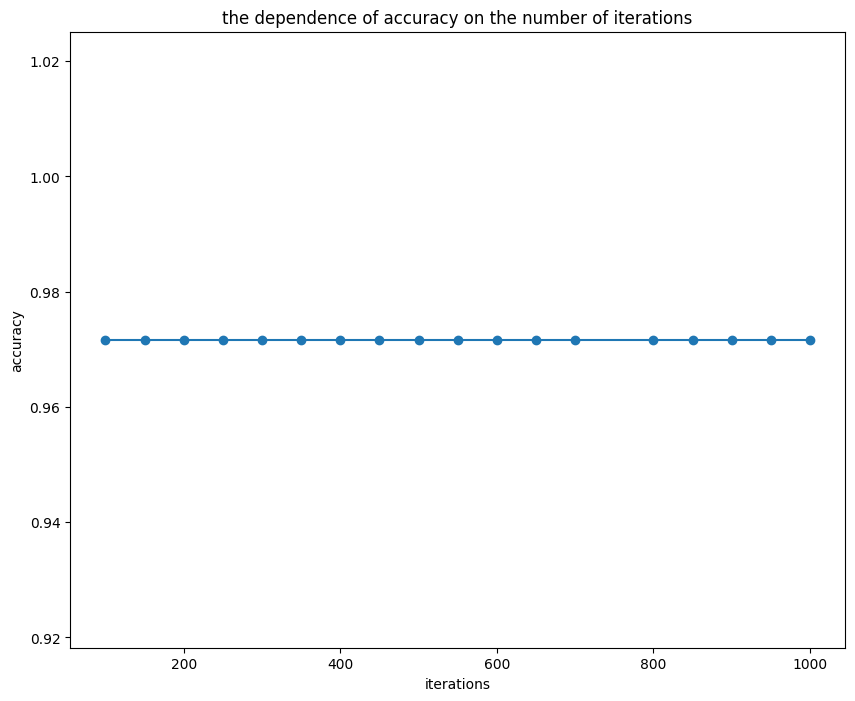

In [48]:
iterationsArr = [100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 800, 850, 900, 950, 1000]

accuracies = []
for iter in iterationsArr:
    mlpcClf = MLPClassifier(
        solver='lbfgs',
        hidden_layer_sizes=(350,),
        max_iter=iter,
        early_stopping=True,
        activation='relu',
        random_state=42
    )
    accuracies.append(calc_accuracy(mlpcClf))
    print(f'iter={iter}, accuracy: {calc_accuracy(mlpcClf)}')

plt.figure(figsize=(10, 8))
plt.plot(iterationsArr, accuracies, marker='o')
plt.title('the dependence of accuracy on the number of iterations')
plt.xlabel('iterations')
plt.ylabel('accuracy')
plt.show()

In [49]:
mlpcClf = MLPClassifier(
    solver='lbfgs',
    hidden_layer_sizes=(350,),
    max_iter=100,
    early_stopping=True,
    activation='relu',
    random_state=42
)
print(f'accuracy: {calc_accuracy(mlpcClf)}')

accuracy: 0.9716666666666667


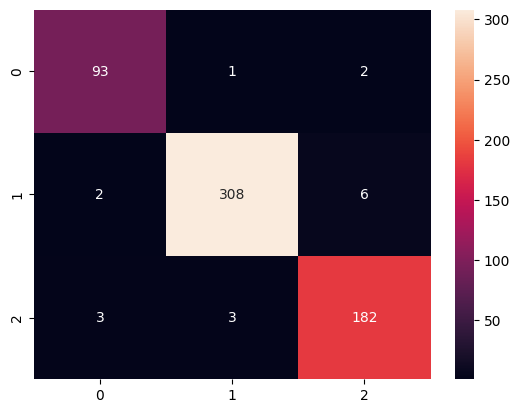

In [51]:
classes_name = ['0', '1', '2']

cm = pd.DataFrame(
    confusion_matrix(yTest, mlpcClf.predict(xTestTransform)),
    columns=classes_name,
    index=classes_name,
)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()